# Quickstart: ML-Corrected 1D Viscous Burgers Solver

This notebook walks through the key components:
1. Run a Burgers simulation and visualize the solution
2. Compare coarse vs fine solvers
3. Visualize correction targets
4. Load a trained model and run the corrected solver

In [1]:
import sys, os, pathlib

# Ensure we run from the project root so relative paths (configs/, data/, etc.) work
os.chdir(pathlib.Path(__file__).parent.parent if '__file__' in dir() else pathlib.Path.cwd().parent)
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import yaml

from src.pde.burgers import BurgersSolver
from src.pde.metrics import energy, relative_l2_error
from src.pde.initial_conditions import get_ic

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Run a single Burgers simulation

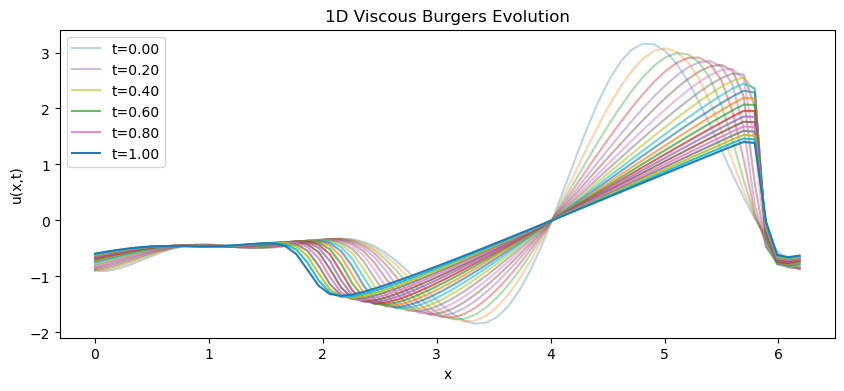

In [2]:
with open('configs/burgers_default.yaml') as f:
    cfg = yaml.safe_load(f)

solver = BurgersSolver(cfg)
history = solver.solve(t_end=1.0, record_interval=50)

fig, ax = plt.subplots()
for i, (t, u) in enumerate(history):
    alpha = 0.3 + 0.7 * i / len(history)
    ax.plot(solver.x, u, alpha=alpha, label=f't={t:.2f}' if i % max(len(history)//5, 1) == 0 else '')
ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title('1D Viscous Burgers Evolution')
ax.legend()
plt.show()

## 2. Coarse vs Fine comparison

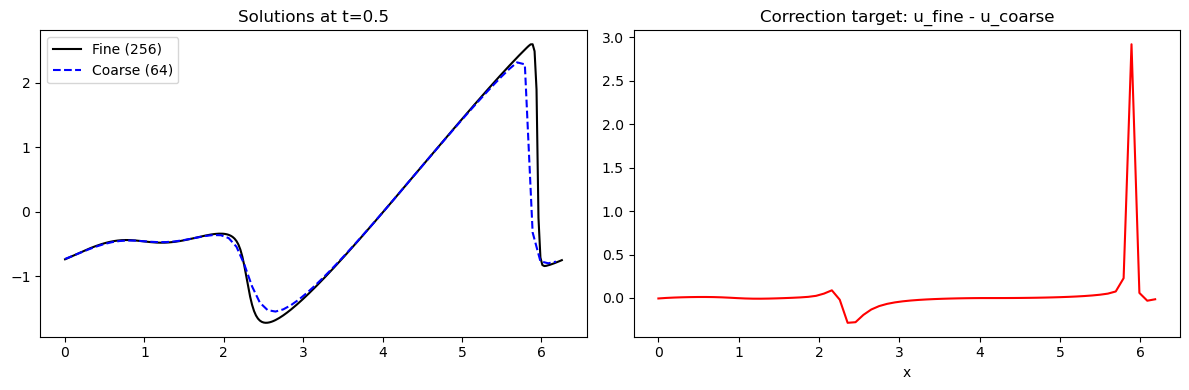

Relative L2 error: 0.3285


In [3]:
from scipy.interpolate import interp1d

solver_coarse = BurgersSolver(cfg, nx_override=64)
solver_fine = BurgersSolver(cfg, nx_override=256)

solver_coarse.solve(t_end=0.5)
solver_fine.solve(t_end=0.5)

# Interpolate fine to coarse grid
interp_fn = interp1d(solver_fine.x, solver_fine.u, kind='linear')
u_fine_on_coarse = interp_fn(solver_coarse.x)
delta_u = u_fine_on_coarse - solver_coarse.u

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(solver_fine.x, solver_fine.u, 'k-', label='Fine (256)')
axes[0].plot(solver_coarse.x, solver_coarse.u, 'b--', label='Coarse (64)')
axes[0].legend()
axes[0].set_title('Solutions at t=0.5')

axes[1].plot(solver_coarse.x, delta_u, 'r-')
axes[1].set_title('Correction target: u_fine - u_coarse')
axes[1].set_xlabel('x')
plt.tight_layout()
plt.show()

dx = solver_coarse.dx
print(f'Relative L2 error: {relative_l2_error(solver_coarse.u, u_fine_on_coarse, dx):.4f}')

## 3. Different initial conditions

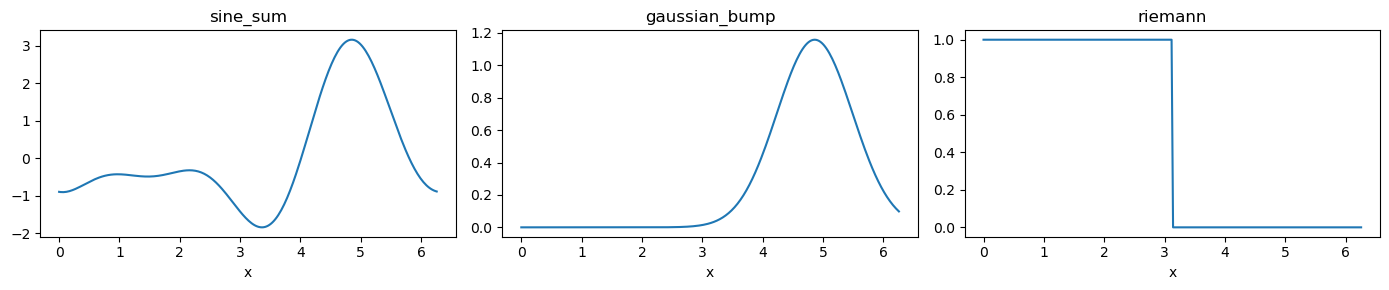

In [4]:
x = np.linspace(0, 2*np.pi, 256, endpoint=False)
ic_types = ['sine_sum', 'gaussian_bump', 'riemann']

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, ic_type in zip(axes, ic_types):
    kwargs = {'seed': 42} if ic_type != 'riemann' else {}
    u0 = get_ic(ic_type, x, **kwargs)
    ax.plot(x, u0)
    ax.set_title(ic_type)
    ax.set_xlabel('x')
plt.tight_layout()
plt.show()

## 4. Load trained model and run corrected solver

Run this cell after training (`bash scripts/train.sh`).

In [ ]:
import os
import torch
from src.models.correction_mlp import CorrectionMLP
from src.models.utils import load_model
from src.data.transforms import StencilNormalizer
from src.train.eval import make_correction_fn

model_path = 'outputs/checkpoints/best_model.pt'
if os.path.exists(model_path):
    model = CorrectionMLP(input_dim=11, hidden_dims=[64, 64, 32])
    model, meta = load_model(model, model_path)
    print(f'Loaded model (val_loss={meta.get("metrics", {}).get("best_val_loss", "?")})')
    
    normalizer = StencilNormalizer()
    normalizer.load('outputs/checkpoints/normalizer.npz')
    correction_fn = make_correction_fn(model, stencil_half_width=3, normalizer=normalizer)
    
    # Run corrected solver
    solver_corrected = BurgersSolver(cfg)
    solver_corrected.solve(t_end=0.5, correction_fn=correction_fn)
    
    solver_fine = BurgersSolver(cfg, nx_override=256)
    solver_fine.solve(t_end=0.5)
    
    solver_coarse = BurgersSolver(cfg)
    solver_coarse.solve(t_end=0.5)
    
    interp_fn = interp1d(solver_fine.x, solver_fine.u, kind='linear')
    u_fine_on_coarse = interp_fn(solver_coarse.x)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(solver_coarse.x, u_fine_on_coarse, 'k-', lw=1.5, label='Fine (reference)')
    ax.plot(solver_coarse.x, solver_coarse.u, 'b--', lw=1.2, label='Coarse')
    ax.plot(solver_corrected.x, solver_corrected.u, 'r-', lw=1.2, label='Corrected')
    ax.legend()
    ax.set_title('Corrected vs Coarse vs Fine at t=0.5')
    plt.show()
    
    dx = solver_coarse.dx
    print(f'Coarse error:    {relative_l2_error(solver_coarse.u, u_fine_on_coarse, dx):.4f}')
    print(f'Corrected error: {relative_l2_error(solver_corrected.u, u_fine_on_coarse, dx):.4f}')
else:
    print('No trained model found. Run: bash scripts/train.sh')